# ATLAS Wind Atlas: scenario plotting

This notebook creates maps from the scenario wind dataset produced by the previous wind conversion notebook.

Expected input files are the final 8 variable NetCDF files produced by `5.2.2_ATLAS_wind_conversion_scenarios`:

```text
u10_corrected
v10_corrected
wds_corrected
dir_corrected
delta_u10
delta_v10
delta_wds
delta_dir
```

The notebook is written as a reusable plotting template. The user only needs to edit the configuration cells.

## Method overview

The notebook opens one scenario wind dataset for the continental area and, when available, one scenario wind dataset for the islands.

It then produces maps for selected variables. For Chile like domains, the continental area is plotted as the main map and the islands are shown as small inset maps.

The plotting logic is the same for all variables. Only the color scale, label and output file name change.

## 0. Load libraries

Run this cell first. It imports the plotting and geospatial libraries used throughout the notebook.

In [2]:
from pathlib import Path
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401. Needed to activate the .rio accessor in xarray
import xarray as xr
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm

warnings.filterwarnings("ignore")

## 1. User settings

Edit only this cell for a standard run.

The notebook expects the scenario conversion output from the previous step. By default it tries to plot both `continental` and `islands`. If the islands file does not exist, the notebook still produces the continental map.

In [3]:
# Country or study area name used in folder names and file names.
COUNTRY = "chile"

# CMIP6 model and scenario used in the previous scenario notebooks.
MODEL = "CNRM-ESM2-1"
EXPERIMENT = "ssp370"

# Future period used in the previous scenario notebooks.
START_YEAR = 2020
END_YEAR = 2050

# Month to plot.
MONTH = 1

# Areas expected from the conversion notebook.
CONTINENTAL_AREA_NAME = "continental"
ISLANDS_AREA_NAME = "islands"

# If True, the notebook tries to add islands as inset maps.
PLOT_ISLANDS_INSETS = True

# Optional boundary shapefile. Set to None if no shapefile is available.
# Example: BOUNDARY_FILE = Path("../data/boundaries/chile_regions.shp")
BOUNDARY_FILE = None

# Output image resolution.
FIGURE_DPI = 150

## 2. Folder configuration

The paths are relative and anonymous, so the notebook can be shared without exposing local server folders.

Expected input:

```text
../data/atlas_data/<country>/<model>/<scenario>/10m_wind_corrected_<country>_m<month>_<scenario>_<area>_<start>_<end>.nc
```

Expected output:

```text
../figures/<country>/<model>/<scenario>/
```

In [5]:
BASE_DIR = Path("../data")
FIGURE_BASE_DIR = Path("../data/figures")

ATLAS_DIR = BASE_DIR / "atlas_data" / COUNTRY / MODEL / EXPERIMENT
OUTPUT_FIGURE_DIR = FIGURE_BASE_DIR / COUNTRY / MODEL / EXPERIMENT
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Input scenario folder:", ATLAS_DIR)
print("Output figure folder:", OUTPUT_FIGURE_DIR)

Input scenario folder: ../data/atlas_data/chile/CNRM-ESM2-1/ssp370
Output figure folder: ../data/figures/chile/CNRM-ESM2-1/ssp370


## 3. Variable configuration

This cell defines the variables that can be plotted. You can remove variables from `VARIABLES_TO_PLOT` if you only need a subset of maps.

In [6]:
VARIABLE_SETTINGS = {
    "u10_corrected": {
        "title": "Future corrected 10 m U wind component",
        "label": "m/s",
        "vmin": -8,
        "vmax": 8,
        "cmap": "RdBu_r",
        "norm": "centered",
        "file_prefix": "u10_corrected",
    },
    "v10_corrected": {
        "title": "Future corrected 10 m V wind component",
        "label": "m/s",
        "vmin": -8,
        "vmax": 8,
        "cmap": "RdBu_r",
        "norm": "centered",
        "file_prefix": "v10_corrected",
    },
    "wds_corrected": {
        "title": "Future corrected 10 m wind speed",
        "label": "m/s",
        "vmin": 0,
        "vmax": 8,
        "cmap": "BuPu",
        "norm": "linear",
        "file_prefix": "wds_corrected",
    },
    "dir_corrected": {
        "title": "Future corrected 10 m wind direction",
        "label": "degrees from North",
        "vmin": 0,
        "vmax": 360,
        "cmap": "twilight",
        "norm": "linear",
        "file_prefix": "dir_corrected",
    },
    "delta_u10": {
        "title": "Projected change in 10 m U wind component",
        "label": "m/s",
        "vmin": -2,
        "vmax": 2,
        "cmap": "RdBu_r",
        "norm": "centered",
        "file_prefix": "delta_u10",
    },
    "delta_v10": {
        "title": "Projected change in 10 m V wind component",
        "label": "m/s",
        "vmin": -2,
        "vmax": 2,
        "cmap": "RdBu_r",
        "norm": "centered",
        "file_prefix": "delta_v10",
    },
    "delta_wds": {
        "title": "Projected change in 10 m wind speed",
        "label": "m/s",
        "vmin": -2,
        "vmax": 2,
        "cmap": "bwr",
        "norm": "centered",
        "file_prefix": "delta_wds",
    },
    "delta_dir": {
        "title": "Projected change in 10 m wind direction",
        "label": "degrees",
        "vmin": -20,
        "vmax": 20,
        "cmap": "bwr",
        "norm": "centered",
        "file_prefix": "delta_dir",
    },
}

# Choose which variables to plot.
VARIABLES_TO_PLOT = [
    "wds_corrected",
    "dir_corrected",
    "delta_wds",
    "delta_dir",
]

# To plot all eight variables, uncomment the following line.
# VARIABLES_TO_PLOT = list(VARIABLE_SETTINGS)

## 4. Optional islands inset settings

These extents are specific to Chile. If the study area is different, either update the values or set `PLOT_ISLANDS_INSETS = False` in the user settings.

In [7]:
ISLAND_INSETS = [
    {
        "name": "Juan Fernandez",
        "extent": [-80.9, -78.7, -34.1, -33.5],
        "position": [0.08, 0.66, 0.32, 0.22],
    },
    {
        "name": "Desventuradas",
        "extent": [-80.2, -79.85, -26.36, -26.25],
        "position": [0.08, 0.40, 0.32, 0.22],
    },
    {
        "name": "Rapa Nui",
        "extent": [-109.6, -109.1, -27.4, -26.9],
        "position": [0.08, 0.14, 0.32, 0.22],
    },
]

## 5. File name helpers

If your previous notebooks use a different file naming convention, update only these functions.

In [8]:
def scenario_wind_file(area_name):
    """Return the scenario wind file produced by the conversion notebook."""
    file_name = (
        f"10m_wind_corrected_"
        f"{COUNTRY}_m{MONTH}_{EXPERIMENT}_{area_name}_{START_YEAR}_{END_YEAR}.nc"
    )
    return ATLAS_DIR / file_name


def figure_file(variable_name):
    """Return the output figure path for one variable."""
    settings = VARIABLE_SETTINGS[variable_name]
    file_name = (
        f"{settings['file_prefix']}_{COUNTRY}_m{MONTH}_"
        f"{EXPERIMENT}_{START_YEAR}_{END_YEAR}.png"
    )
    return OUTPUT_FIGURE_DIR / file_name

## 6. Open input data

This cell opens the continental dataset and, when available, the islands dataset.

In [9]:
def open_scenario_dataset(area_name, required=True):
    """Open one scenario wind dataset and attach the EPSG:4326 coordinate reference system."""
    path = scenario_wind_file(area_name)

    if not path.exists():
        message = f"Scenario file not found for area '{area_name}': {path}"
        if required:
            raise FileNotFoundError(message)
        print(message)
        return None

    print(f"Opening {area_name} dataset:", path)
    ds = xr.open_dataset(path, chunks={"latitude": 1000, "longitude": 1000})
    ds = ds.rio.write_crs("EPSG:4326")
    ds = ds.drop_vars("spatial_ref", errors="ignore")
    return ds


xdf_continent = open_scenario_dataset(CONTINENTAL_AREA_NAME, required=True)
xdf_islands = open_scenario_dataset(ISLANDS_AREA_NAME, required=False)

print("Continental variables:", list(xdf_continent.data_vars))
if xdf_islands is not None:
    print("Islands variables:", list(xdf_islands.data_vars))

Opening continental dataset: ../data/atlas_data/chile/CNRM-ESM2-1/ssp370/10m_wind_corrected_chile_m1_ssp370_continental_2020_2050.nc
Opening islands dataset: ../data/atlas_data/chile/CNRM-ESM2-1/ssp370/10m_wind_corrected_chile_m1_ssp370_islands_2020_2050.nc
Continental variables: ['u10_corrected', 'v10_corrected', 'wds_corrected', 'dir_corrected', 'delta_u10', 'delta_v10', 'delta_wds', 'delta_dir']
Islands variables: ['u10_corrected', 'v10_corrected', 'wds_corrected', 'dir_corrected', 'delta_u10', 'delta_v10', 'delta_wds', 'delta_dir']


## 7. Open optional boundaries

If a boundary shapefile is provided, it is plotted on top of the maps. Otherwise the notebook uses only Cartopy coastlines and borders.

In [10]:
def load_boundaries(boundary_file):
    """Load optional geographic boundaries."""
    if boundary_file is None:
        return None

    boundary_file = Path(boundary_file)
    if not boundary_file.exists():
        print("Boundary file not found. Continuing without boundaries:", boundary_file)
        return None

    boundaries = gpd.read_file(boundary_file)
    boundaries = boundaries.to_crs("EPSG:4326")
    return boundaries


boundaries = load_boundaries(BOUNDARY_FILE)

## 8. Plotting helper functions

These functions are reused for all maps.

In [11]:
def get_spatial_names(da):
    """Return latitude and longitude names used by a DataArray."""
    lat_candidates = ["latitude", "lat", "y"]
    lon_candidates = ["longitude", "lon", "x"]

    lat_name = next((name for name in lat_candidates if name in da.coords or name in da.dims), None)
    lon_name = next((name for name in lon_candidates if name in da.coords or name in da.dims), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            "Could not identify latitude and longitude coordinates. "
            f"Available coordinates are: {list(da.coords)}"
        )

    return lat_name, lon_name


def standardize_spatial_names(data):
    """Rename spatial coordinates to latitude and longitude when needed."""
    lat_name, lon_name = get_spatial_names(data)
    rename = {}
    if lat_name != "latitude":
        rename[lat_name] = "latitude"
    if lon_name != "longitude":
        rename[lon_name] = "longitude"
    if rename:
        data = data.rename(rename)
    return data


def cell_edges(coord):
    """Calculate cell edges from cell centres for pcolormesh."""
    coord = np.asarray(coord, dtype=float)
    if coord.size < 2:
        raise ValueError("At least two coordinate values are required to calculate cell edges.")

    d = np.diff(coord)
    edges = np.empty(coord.size + 1)
    edges[1:-1] = coord[:-1] + d / 2
    edges[0] = coord[0] - d[0] / 2
    edges[-1] = coord[-1] + d[-1] / 2
    return edges


def subset_by_extent(data, extent):
    """Subset a DataArray using an extent in lon_min, lon_max, lat_min, lat_max order."""
    xmin, xmax, ymin, ymax = extent
    data = standardize_spatial_names(data)

    lat = data.latitude
    if lat[0] > lat[-1]:
        lat_slice = slice(ymax, ymin)
    else:
        lat_slice = slice(ymin, ymax)

    return data.sel(longitude=slice(xmin, xmax), latitude=lat_slice)


def make_norm(settings):
    """Create the color normalization object for one variable."""
    vmin = settings.get("vmin")
    vmax = settings.get("vmax")

    if settings.get("norm") == "centered":
        return TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    return Normalize(vmin=vmin, vmax=vmax)


def prepare_dataarray(ds, variable_name):
    """Extract one variable, standardize coordinates and sort the grid."""
    if variable_name not in ds.data_vars:
        raise KeyError(
            f"Variable '{variable_name}' was not found. "
            f"Available variables are: {list(ds.data_vars)}"
        )

    data = standardize_spatial_names(ds[variable_name])
    data = data.sortby("latitude").sortby("longitude")
    data = data.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    data = data.rio.write_crs("EPSG:4326")
    return data

## 9. Map drawing functions

The main map shows the continental area. Islands are added as insets when the islands dataset exists and the inset option is active.

In [12]:
def add_base_layers(ax):
    """Add simple geographic layers to a Cartopy axis."""
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")
    ax.add_feature(cfeature.RIVERS, edgecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)


def add_gridlines(ax, label_size=10):
    """Add formatted longitude and latitude gridlines."""
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": label_size}
    gl.ylabel_style = {"size": label_size}
    return gl


def plot_boundaries(ax):
    """Plot optional study area boundaries."""
    if boundaries is not None:
        boundaries.boundary.plot(
            ax=ax,
            edgecolor="black",
            linewidth=0.6,
            transform=ccrs.PlateCarree(),
        )


def plot_data_on_axis(ax, data, cmap, norm):
    """Plot one gridded DataArray on a Cartopy axis."""
    data = data.sortby("latitude").sortby("longitude")

    lon = data.longitude.values
    lat = data.latitude.values
    values = np.ma.masked_invalid(data.values)

    lon_edges = cell_edges(lon)
    lat_edges = cell_edges(lat)
    lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)

    image = ax.pcolormesh(
        lon2d,
        lat2d,
        values,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="flat",
    )
    return image


def plot_inset(ax, data, title, extent, cmap, norm):
    """Plot one islands inset."""
    subset = subset_by_extent(data, extent)
    plot_data_on_axis(ax, subset, cmap, norm)
    plot_boundaries(ax)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12, pad=2)
    add_gridlines(ax, label_size=8)


def draw_map(variable_name, continent_ds, islands_ds=None, save=True):
    """Draw and save one scenario map."""
    settings = VARIABLE_SETTINGS[variable_name]

    continent_data = prepare_dataarray(continent_ds, variable_name)
    islands_data = prepare_dataarray(islands_ds, variable_name) if islands_ds is not None else None

    cmap = settings["cmap"]
    norm = make_norm(settings)

    fig = plt.figure(figsize=(10, 14))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    add_base_layers(ax)
    image = plot_data_on_axis(ax, continent_data, cmap, norm)
    plot_boundaries(ax)

    lon = continent_data.longitude.values
    lat = continent_data.latitude.values
    ax.set_extent([lon.min() - 1, lon.max() + 1, lat.min() - 1, lat.max() + 1], crs=ccrs.PlateCarree())

    add_gridlines(ax, label_size=10)
    ax.set_title(settings["title"], fontsize=22)

    colorbar = fig.colorbar(image, ax=ax, shrink=0.75, pad=0.03, aspect=30)
    colorbar.set_label(settings["label"], fontsize=16)

    if PLOT_ISLANDS_INSETS and islands_data is not None:
        fig.subplots_adjust(left=0.42, right=0.88)
        for inset in ISLAND_INSETS:
            ax_inset = fig.add_axes(inset["position"], projection=ccrs.PlateCarree())
            plot_inset(
                ax_inset,
                islands_data,
                title=inset["name"],
                extent=inset["extent"],
                cmap=cmap,
                norm=norm,
            )
    else:
        fig.subplots_adjust(left=0.08, right=0.92)

    output_path = figure_file(variable_name)
    if save:
        fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
        print("Saved figure:", output_path)
        plt.close(fig)

    return fig

## 10. Create maps

This cell creates one PNG file for each variable listed in `VARIABLES_TO_PLOT`.

In [13]:
generated_figures = []

for variable_name in VARIABLES_TO_PLOT:
    print("=" * 80)
    print("Plotting variable:", variable_name)
    draw_map(variable_name, xdf_continent, xdf_islands, save=True)
    generated_figures.append(figure_file(variable_name))

print("=" * 80)
print("Scenario plotting completed.")
print("Generated figures:")
for path in generated_figures:
    print(path)

Plotting variable: wds_corrected
Saved figure: ../data/figures/chile/CNRM-ESM2-1/ssp370/wds_corrected_chile_m1_ssp370_2020_2050.png
Plotting variable: dir_corrected
Saved figure: ../data/figures/chile/CNRM-ESM2-1/ssp370/dir_corrected_chile_m1_ssp370_2020_2050.png
Plotting variable: delta_wds
Saved figure: ../data/figures/chile/CNRM-ESM2-1/ssp370/delta_wds_chile_m1_ssp370_2020_2050.png
Plotting variable: delta_dir
Saved figure: ../data/figures/chile/CNRM-ESM2-1/ssp370/delta_dir_chile_m1_ssp370_2020_2050.png
Scenario plotting completed.
Generated figures:
../data/figures/chile/CNRM-ESM2-1/ssp370/wds_corrected_chile_m1_ssp370_2020_2050.png
../data/figures/chile/CNRM-ESM2-1/ssp370/dir_corrected_chile_m1_ssp370_2020_2050.png
../data/figures/chile/CNRM-ESM2-1/ssp370/delta_wds_chile_m1_ssp370_2020_2050.png
../data/figures/chile/CNRM-ESM2-1/ssp370/delta_dir_chile_m1_ssp370_2020_2050.png


## 11. Optional quick preview

Use this cell to display one map inside the notebook without saving it again.

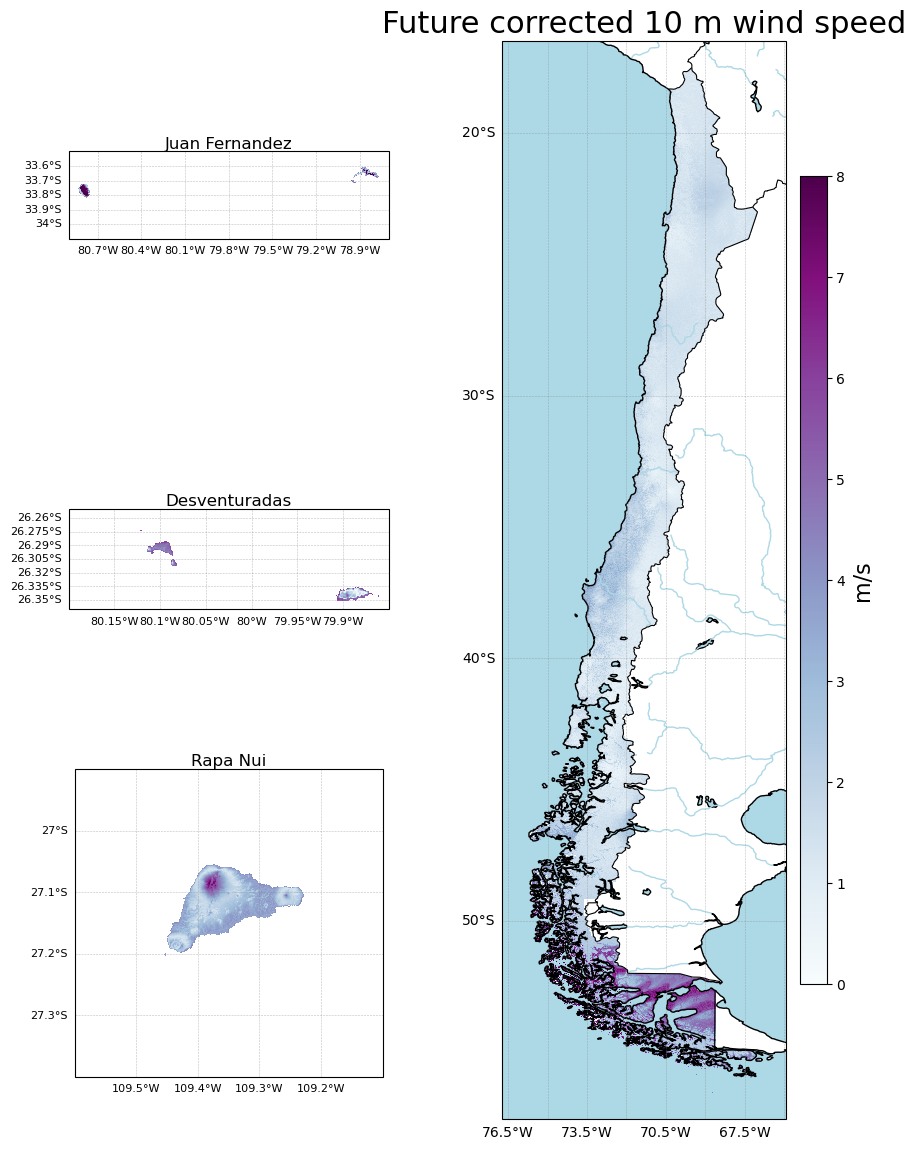

In [15]:
#Example preview. Change the variable name if needed.
fig = draw_map("wds_corrected", xdf_continent, xdf_islands, save=False)
plt.show()